In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hesh97/titanicdataset-traincsv/train.csv


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

**LOAD DATASET**

In [3]:
df=pd.read_csv("/kaggle/input/datasets/hesh97/titanicdataset-traincsv/train.csv")

**EDA**

In [4]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**HANDLING MISSING VALUE**

In [9]:
df["Age"]=df["Age"].fillna(np.mean(df["Age"]))

In [10]:
df.drop(columns=["PassengerId","Name","Ticket","Cabin"],inplace=True)

Dropping Column Which Doesn't have much importance in predicting Survived or Not. 

In [11]:
df.shape

(891, 8)

In [12]:
df["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [13]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [14]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [15]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [16]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

MORE MALE

**UNDERSTANDING RELATIONSHIP WITH GRAPHS**

<Axes: xlabel='Survived', ylabel='count'>

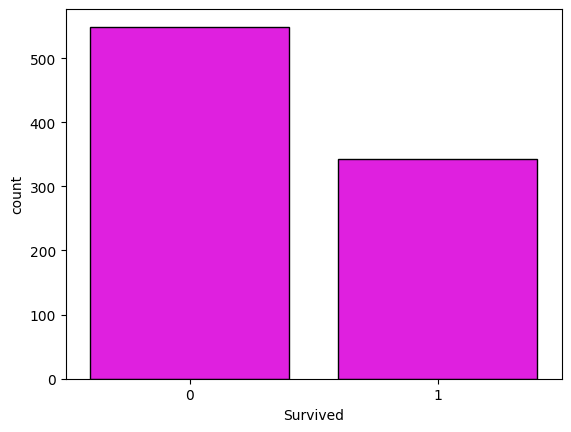

In [17]:
sns.countplot(data=df,x=df["Survived"],color="magenta",edgecolor="black")

**FROM ABOVE GRAPH :-**
No of people **Died** is more than who survived.

<Axes: xlabel='Sex', ylabel='count'>

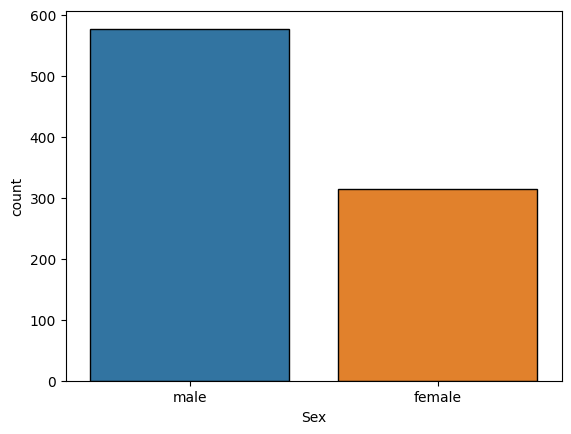

In [18]:
sns.countplot(data=df,x="Sex",hue="Sex",edgecolor="black")

FEMALE SURVIVED MORE THAN THAT OF MALE.
ie-FEMALE HAVE BETTER SURVIVAL RATE

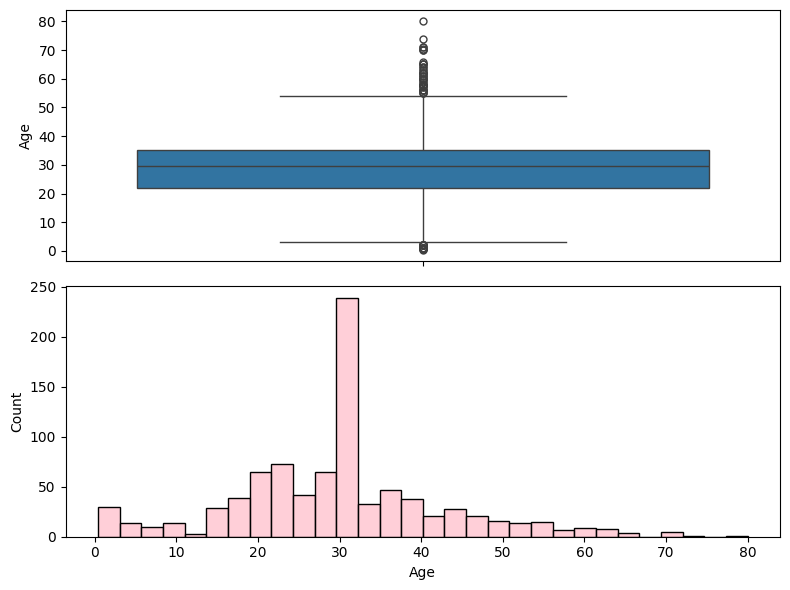

In [19]:
plt.figure(figsize=(8,6))

plt.subplot(2,1,1)
sns.boxplot(data=df,y=df["Age"],fliersize=5)

plt.subplot(2,1,2)
sns.histplot(df["Age"],color="pink",edgecolor="black")
plt.tight_layout()



1--Age Column has some outlier.
2--Most of the passenger are Young.

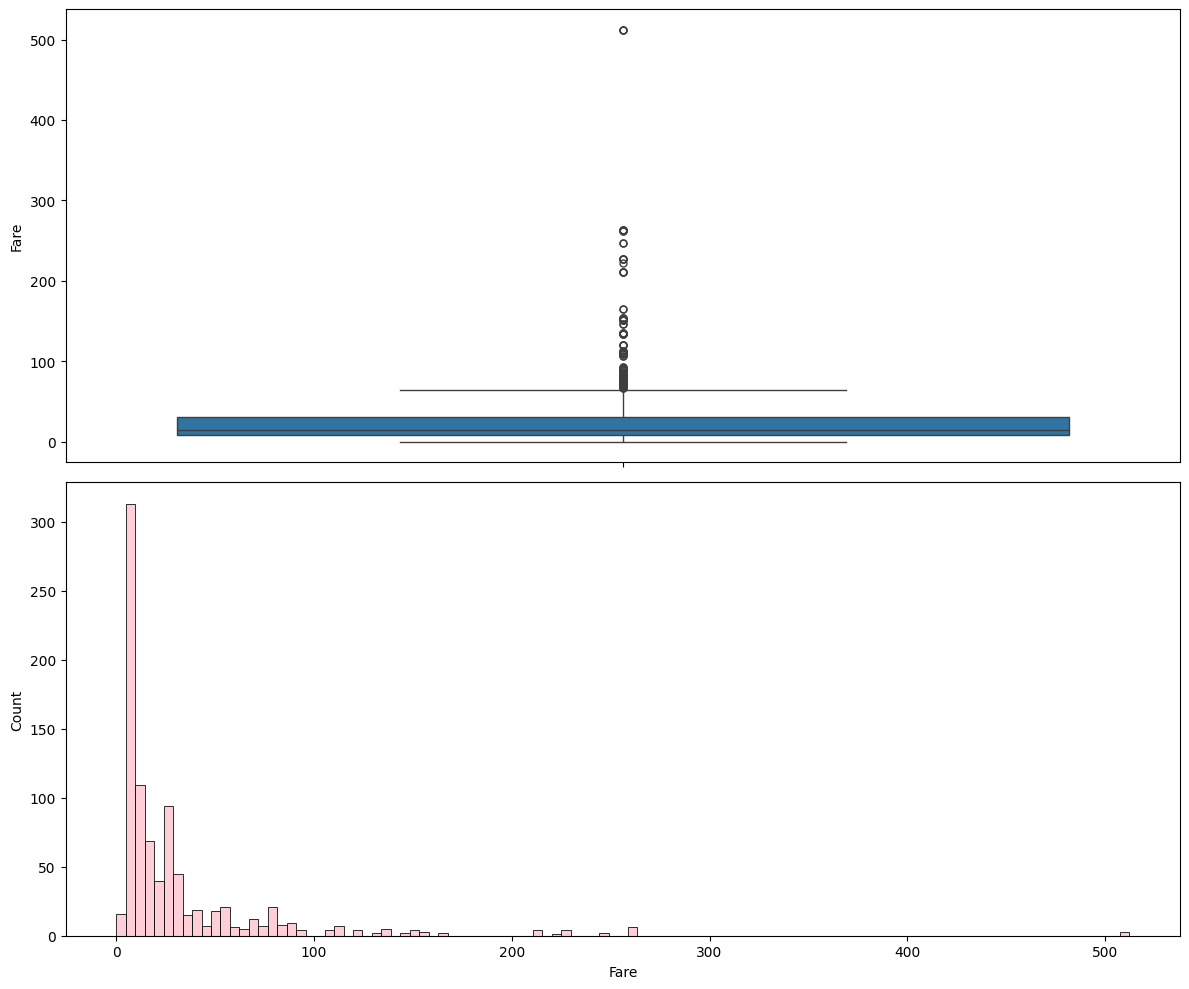

In [20]:
plt.figure(figsize=(12,10))

plt.subplot(2,1,1)
sns.boxplot(data=df,y=df["Fare"],fliersize=5)

plt.subplot(2,1,2)
sns.histplot(df["Fare"],color="pink",edgecolor="black")
plt.tight_layout()



1--Fare is Not Skewed as much.
2--Most Of Fare Under 100.

<Axes: ylabel='count'>

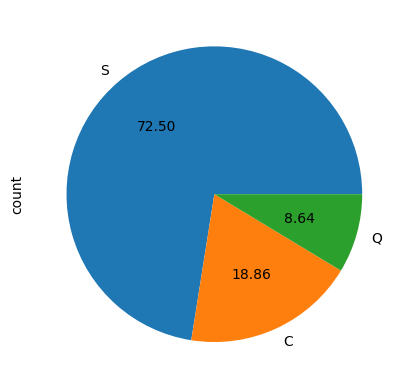

In [21]:
df["Embarked"].value_counts().plot(kind="pie",labels=df["Embarked"].value_counts().index,autopct="%.2f")


Most Of Passenger Boaded From S Port.

Text(0, 0.5, 'Fare')

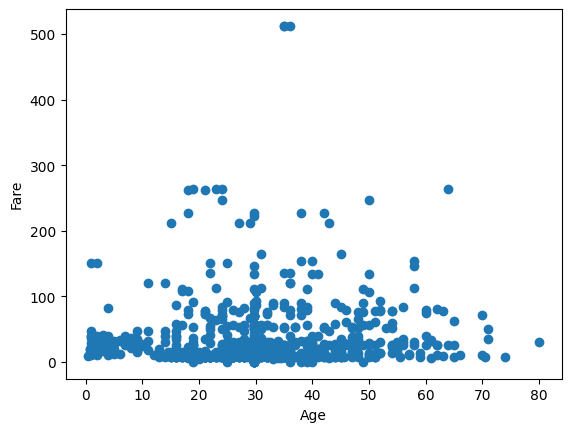

In [22]:
plt.scatter(df["Age"],df["Fare"])
plt.xlabel("Age")
plt.ylabel("Fare")

1--Mostly All Age People have Fare lie below 100.

In [23]:
df.tail()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
886,0,2,male,27.000000,0,0,13.00,S
887,1,1,female,19.000000,0,0,30.00,S
888,0,3,female,29.699118,1,2,23.45,S
889,1,1,male,26.000000,0,0,30.00,C
890,0,3,male,32.000000,0,0,7.75,Q


**ML WORKFLOW**

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=["Survived"]),df["Survived"],test_size=0.2,random_state=42)

In [25]:
X_train.sample(3)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
750,2,female,4.000000,1,1,23.00,S
648,3,male,29.699118,0,0,7.55,S
41,2,female,27.000000,1,0,21.00,S


**ENCORDING ON Sex,Embarked **

In [26]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
A=ColumnTransformer([("Sex_embarked_E",OneHotEncoder(sparse_output=False,handle_unknown='ignore'),[1,6]),("Scale",StandardScaler(),[2,5])],remainder="passthrough")

**Scalling One Age,Fare**

In [27]:
B=ColumnTransformer([("Scale",StandardScaler(),[2,5])],remainder="passthrough")

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
C=LogisticRegression()
D=DecisionTreeClassifier()
E=RandomForestClassifier()

In [29]:
from sklearn.pipeline import make_pipeline,Pipeline
pipe=make_pipeline(A,B,C)
pipe.fit(X_train,y_train)


Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Sex_embarked_E',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 6]),
                                                 ('Scale', StandardScaler(),
                                                  [2, 5])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Scale', StandardScaler(),
                                                  [2, 5])])),
                ('logisticregression', LogisticRegression())])

In [30]:
pipe_d=make_pipeline(A,B,D)
pipe_d.fit(X_train,y_train)


Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Sex_embarked_E',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 6]),
                                                 ('Scale', StandardScaler(),
                                                  [2, 5])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Scale', StandardScaler(),
                                                  [2, 5])])),
                ('decisiontreeclassifier', DecisionTreeClassifier())])

In [31]:
pipe_F=make_pipeline(A,B,E)
pipe_F.fit(X_train,y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Sex_embarked_E',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 6]),
                                                 ('Scale', StandardScaler(),
                                                  [2, 5])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Scale', StandardScaler(),
                                                  [2, 5])])),
                ('randomforestclassifier', RandomForestClassifier())])

In [32]:
y_pred=pipe.predict(X_test)
y_pred_d=pipe_d.predict(X_test)
y_pred_F=pipe_F.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score
print("Accuracy_BY_LogisticRegression Model")
x=accuracy_score(y_test,y_pred)
x

Accuracy_BY_LogisticRegression Model


0.8100558659217877

In [34]:
print("Accuracy By Decision_Tree_Classifier Model")
y=accuracy_score(y_test,y_pred_d)
y

Accuracy By Decision_Tree_Classifier Model


0.770949720670391

In [35]:
print("Accuracy By Random Forest Classifier")
z=accuracy_score(y_test,y_pred_F)
z

Accuracy By Random Forest Classifier


0.8212290502793296

In [36]:
pd.DataFrame({"MODEL":["LOGESTIC_REGRESSION","DECISION_TREE_CLASSIFIER","RANDOM_FOREST_CLASSIFIER"],"ACCURACY":[x*100,y*100,z*100]})

,MODEL,ACCURACY
0,LOGESTIC_REGRESSION,81.005587
1,DECISION_TREE_CLASSIFIER,77.094972
2,RANDOM_FOREST_CLASSIFIER,82.122905


In [37]:
from sklearn.metrics import confusion_matrix
cma=confusion_matrix(y_test,y_pred)
cma

array([[90, 15],
       [19, 55]])

In [38]:
cmb=confusion_matrix(y_test,y_pred_d)
cmb

array([[84, 21],
       [20, 54]])

In [39]:
cmc=confusion_matrix(y_test,y_pred_F)
cmc

array([[92, 13],
       [19, 55]])

**USE OF CROSS_VAL_SCORE FOR ACCURACY**

In [40]:
from sklearn.model_selection import cross_val_score
print("BY Logestic Regression")
cross_val_score(pipe,X_train,y_train,cv=3).mean()

BY Logestic Regression


np.float64(0.7963573615100049)

In [41]:
print("BY Decision_Tree_Classifier")
cross_val_score(pipe_d,X_train,y_train,cv=3).mean()

BY Decision_Tree_Classifier


np.float64(0.7640203760829226)

In [42]:
print("BY Random_Forest_Classifier")
cross_val_score(pipe_F,X_train,y_train,cv=3).mean()*100

BY Random_Forest_Classifier


np.float64(79.49568012859153)